In [1]:
import timm
import torch
import matplotlib.pyplot as plt
from src.utils.FineTuneUtils import EarlyStopping, train_model, eval_loop, check_top5_accuracy
from torchvision import transforms
from torchvision.datasets import CIFAR100
from torch.utils.data import DataLoader, random_split, Subset
from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss


In [2]:
#creazione del modello
device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = 100
model = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=num_classes).to(device)

In [3]:
#creazione delle trasformazioni
#si usano media e deviazione standard di imagenet su cui il modello è preaddestrato

data_config = timm.data.resolve_model_data_config(model)
imagenet_mean, imagenet_std = data_config["mean"], data_config["std"]

test_transform = transforms.Compose(
    [transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])

val_transform = transforms.Compose(
    [transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print(imagenet_mean, imagenet_std)

(0.5, 0.5, 0.5) (0.5, 0.5, 0.5)


In [69]:
batch_size = 128
N_epochs = 30
backbone_lr = 0.5e-5
head_lr = 0.5e-4
weight_decay = 0.05

In [70]:
#creazione dei dataset e dataloader

#train_set = ImageFolder("D:\\Tesi\\Sets\\Set1\\train", transform=train_transform)
#val_set = ImageFolder("D:\\Tesi\\Sets\\Set1\\val", transform=val_transform)
#test_set = ImageFolder("D:\\Tesi\\Places365Simplified\\val", transform=test_transform)

total_size = 50000
train_size = int(0.9 * total_size)
val_size = total_size - train_size

train_set = CIFAR100(root="D:\\Tesi\\CIFAR100", train=True, download=True, transform=train_transform)
val_set = CIFAR100(root="D:\\Tesi\\CIFAR100", train=True, download=True, transform=val_transform)
test_set = CIFAR100(root="D:\\Tesi\\CIFAR100", train=False, download=True, transform=test_transform)

generator = torch.Generator().manual_seed(42)
train_split, val_split = random_split(train_set, [train_size, val_size], generator=generator)

train_set = Subset(train_set, train_split.indices)
val_set = Subset(val_set, val_split.indices)

print(f"Train size: {len(train_set)}")
print(f"Val size: {len(val_set)}")
print(f"Test size: {len(test_set)}")

classes = train_set.dataset.classes

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

Train size: 45000
Val size: 5000
Test size: 10000


In [71]:
#discriminative learning rates

#prelevo i pesi della backbone controllando che non siano quelli della head
head_params_pointers = set(p.data_ptr() for p in model.head.parameters())
backbone_params = [p for p in model.parameters() if p.data_ptr() not in head_params_pointers]

param_groups = [
    {
        "params": backbone_params,
        "lr": backbone_lr,
    },
    {
        "params": model.head.parameters(),
        "lr": head_lr,
    }
]

optim = AdamW(param_groups, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optim, T_max=N_epochs, eta_min=1e-7)
loss_fn = CrossEntropyLoss()

In [72]:
_, acc, y_true, y_pred = eval_loop(model, val_loader, loss_fn, device, classes)
print(f"Top5 accuracy: {check_top5_accuracy(model, val_loader, device):.2f}%")
print(f"Top1 accuracy: {acc*100:.2f}%")

Top5 accuracy: 4.46%
Top1 accuracy: 1.12%


In [73]:
early_stopping = EarlyStopping(path="D:\\Tesi\\FirstFineTuning", patience=3 ,min_delta=0.001)

train_loss, val_loss, accuracy = train_model(model, N_epochs, optimizer=optim, device=device,
                                             train_dataloader=train_loader, loss_fn=loss_fn,
                                             early_stopping=early_stopping, val_dataloader=val_loader,
                                             scheduler=scheduler)


Epoch 1:   9%|▉         | 32/352 [00:10<01:49,  2.93it/s]


KeyboardInterrupt: 

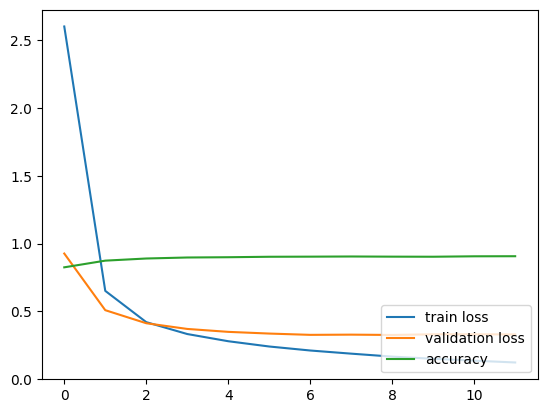

In [54]:
plt.plot(train_loss, label="train loss")
plt.plot(val_loss, label="validation loss")
plt.plot(accuracy, label='accuracy')
plt.legend(loc='lower right')
plt.show()

In [74]:
checkpoint = torch.load("D:\\Tesi\\FirstFineTuning\\best_model.pth")
model.load_state_dict(checkpoint['model_state_dict'])
_, _, y_true, y_pred = eval_loop(model, test_loader, loss_fn, device, classes, report=True)
print(f"Top5 accuracy: {check_top5_accuracy(model, test_loader, device):.2f}%")

               precision    recall  f1-score   support

        apple      0.979     0.950     0.964       100
aquarium_fish      0.933     0.970     0.951       100
         baby      0.862     0.810     0.835       100
         bear      0.908     0.890     0.899       100
       beaver      0.786     0.880     0.830       100
          bed      0.923     0.960     0.941       100
          bee      0.950     0.950     0.950       100
       beetle      0.892     0.910     0.901       100
      bicycle      0.960     0.950     0.955       100
       bottle      0.960     0.970     0.965       100
         bowl      0.798     0.790     0.794       100
          boy      0.747     0.650     0.695       100
       bridge      0.928     0.900     0.914       100
          bus      0.886     0.930     0.907       100
    butterfly      0.950     0.950     0.950       100
        camel      0.969     0.930     0.949       100
          can      0.950     0.960     0.955       100
       ca